In [1]:
from data_loader import get_train_test_split

ds_train, ds_test = get_train_test_split()
print("Training puzzles:", len(ds_train))
print("Testing puzzles:", len(ds_test))

c:\Users\kunri\miniconda3\envs\cs175\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Training puzzles: 521
Testing puzzles: 131


In [2]:
from conn.solvers import RandomSolver

solver = RandomSolver()

def solve_puzzle(words16):
    return solver.solve(words16)

row0 = ds_train[0]
words16 = row0["words"]

print("Puzzle date:", row0.get("date"))
print("All words:", words16)

pred_groups = solve_puzzle(words16)
print("\nPredicted groups (random):")
for g in pred_groups:
    print(g)

print("\nGold groups:")
for ans in row0["answers"]:
    print(ans["answerDescription"], "->", ans["words"])

Puzzle date: 2025-02-09 00:00:00
All words: ['GIANT', 'JUMBO', 'MONSTER', 'SUPER', 'BOWL', 'LADLE', 'POT', 'SPOON', 'CHARACTER', 'INDIVIDUAL', 'PARTY', 'PERSON', 'ALIEN', 'AVATAR', 'DUNE', 'TRON']

Predicted groups (random):
['MONSTER', 'ALIEN', 'CHARACTER', 'AVATAR']
['TRON', 'SPOON', 'BOWL', 'SUPER']
['JUMBO', 'POT', 'INDIVIDUAL', 'GIANT']
['LADLE', 'PERSON', 'PARTY', 'DUNE']

Gold groups:
MASSIVE -> ['GIANT', 'JUMBO', 'MONSTER', 'SUPER']
USED WHEN SERVING SOUP -> ['BOWL', 'LADLE', 'POT', 'SPOON']
SOMEBODY -> ['CHARACTER', 'INDIVIDUAL', 'PARTY', 'PERSON']
SCI-FI FRANCHISES -> ['ALIEN', 'AVATAR', 'DUNE', 'TRON']


In [3]:
from conn import accuracy_min_swaps, accuracy_zero_one, evaluate
from data_loader import gold_groups_from_row
N_EVAL = len(ds_test)

results = evaluate(
    ds_test,
    metric_fns=[accuracy_zero_one, accuracy_min_swaps],
    solver_fn=solve_puzzle,
    max_samples=N_EVAL,
    gold_from_row=gold_groups_from_row,
)

acc, n_eval = results["accuracy_zero_one"]
mean_swaps, _ = results["accuracy_min_swaps"]
print(f"Zero-one accuracy: {acc:.4f}  (n={n_eval}, requested={N_EVAL})")
print(f"Mean 1-1 swaps to correct: {mean_swaps:.2f}  (n={N_EVAL})")


Zero-one accuracy: 0.0000  (n=131, requested=131)
Mean 1-1 swaps to correct: 4.31  (n=131)


The code below generates the distribution of min_swaps using random grouping across a larger n. This helps visualize the metric better

In [4]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
#PREVENTS kernel from dying

words16 = ["0","1","2","3","4","5","6","7","8","9","10","11","12","13","14","15"]
n = 100000
min_swaps_dict = {}
for i in range(n):
    pred_groups = solve_puzzle(words16)
    gold_groups = [["0","1","2","3"], ["4","5","6","7"], ["8","9","10","11"], ["12","13","14","15"]]
    swaps = accuracy_min_swaps(pred_groups, gold_groups)
    if swaps not in min_swaps_dict:
        min_swaps_dict[swaps] = 0
    min_swaps_dict[swaps] += 1

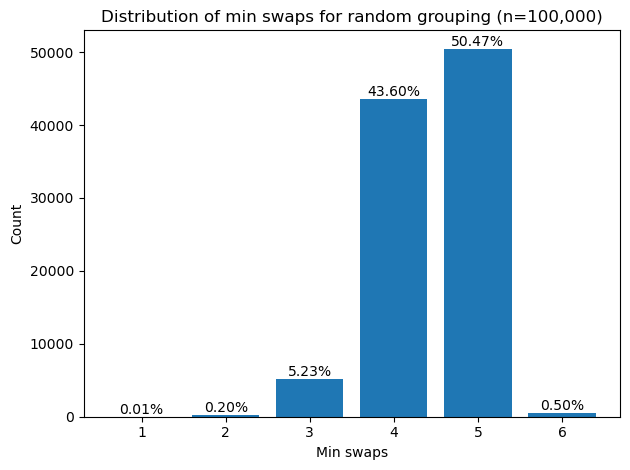

In [10]:
import matplotlib.pyplot as plt

labels = sorted(min_swaps_dict.keys())
counts = [min_swaps_dict[k] for k in labels]
total = sum(counts)

fig, ax = plt.subplots()
bars = ax.bar(labels, counts)

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{100*count/total:.2f}%", ha="center", va="bottom")

ax.set_xlabel("Min swaps")
ax.set_ylabel("Count")
ax.set_title("Distribution of min swaps for random grouping (n=100,000)")
ax.set_xticks(labels)
plt.tight_layout()
plt.show()